# Design of Experiment: perovskite thin film optimization PLQY and FWHM (pymoo)

This notebook is made to use optimPV for experimental design. Here, we show how to load some data from a presampling, and how to use optimPV to suggest the next set of experiment using Bayesian optimization.  
The goal here is to do multi-objective optimization (MO) to maximize the photoluminescence quantum yield (PLQY) and minimize the full width at half maximum (FWHM) of a perovskite thin film.

Note: The data used here is real data generated in the [i-MEET](https://www.i-meet.ww.uni-erlangen.de/) and [HI-ERN](https://www.hi-ern.de/de) labs at the university of Erlangen-Nuremberg (FAU) by Frederik Schmitt. The data is not published yet, and is only used here for demonstration purposes. For more information, please contact us.


In [1]:
# Import necessary libraries
import warnings, os, sys
# remove warnings from the output
os.environ["PYTHONWARNINGS"] = "ignore"
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

try:
    from optimpv import *
    from optimpv.optimizers.pymooOpti.pymooOptimizer import PymooOptimizer
except Exception as e:
    sys.path.append('../') # add the path to the optimpv module
    from optimpv import *
    from optimpv.optimizers.pymooOpti.pymooOptimizer import PymooOptimizer

## Get the data

In [2]:
# Define the path to the data 
data_dir =os.path.join(os.path.abspath('../'),'Data','pero_MOO_opti') # path to the data directory

# Load the data
df = pd.read_csv(os.path.join(data_dir,'Pero_PLQY_FWHM.csv'),sep=r',') # load the data

stepsize_fraction = 0.05
stepsize_spin_speed = 100

# Display some information about the data
print(df.describe())


        iteration   batch_number  Cs_fraction  Fa_fraction  Ma_fraction  \
count  128.000000     128.000000   128.000000   128.000000   128.000000   
mean     3.500000       7.500000     0.209375     0.533984     0.256641   
std      2.300291       4.627885     0.278052     0.361914     0.277742   
min      0.000000       0.000000     0.000000     0.000000     0.000000   
25%      1.750000       3.750000     0.000000     0.200000     0.050000   
50%      3.500000       7.500000     0.050000     0.500000     0.100000   
75%      5.250000      11.250000     0.400000     0.950000     0.462500   
max      7.000000      15.000000     1.000000     1.000000     1.000000   

       Spin_duration_Antisolvent  Spin_duration_High_Speed   Spin_speed  \
count                 128.000000                128.000000   128.000000   
mean                   14.617188                 40.531250  2914.843750   
std                     7.183885                 14.651295  1015.400301   
min                     

## Define the parameters for the simulation

In [3]:
params = [] # list of parameters to be optimized

Cs_fraction = FitParam(name = 'Cs_fraction', value = 0, bounds = [0,1], value_type = 'float', display_name='Cs fraction', unit='', axis_type = 'linear')
params.append(Cs_fraction)

Fa_fraction = FitParam(name = 'Fa_fraction', value = 0, bounds = [0,1], value_type = 'float', display_name='Fa fraction', unit='', axis_type = 'linear')
params.append(Fa_fraction)

Spin_duration_Antisolvent = FitParam(name = 'Spin_duration_Antisolvent', value = 10, bounds = [5,30], value_type = 'float', display_name='Spin duration Antisolvent', unit='s', axis_type = 'linear')
params.append(Spin_duration_Antisolvent)

Spin_duration_High_Speed = FitParam(name = 'Spin_duration_High_Speed', value = 20, bounds = [15,60], value_type = 'float', display_name='Spin duration High Speed', unit='s', axis_type = 'linear')
params.append(Spin_duration_High_Speed)

Spin_speed = FitParam(name = 'Spin_speed', value = 1000, bounds = [1000,5000], value_type = 'float', display_name='Spin speed', unit='rpm', axis_type = 'linear')
params.append(Spin_speed)


## Run the optimization

In [4]:
# Define the Agent and the target metric/loss function
from optimpv.general.SuggestOnlyAgent import SuggestOnlyAgent
threshold = [0.5, 50] # thresholds for the metrics
suggest = SuggestOnlyAgent(params,exp_format=['PLQY', 'FWHM'],minimize=[False,True],name=None,threshold=threshold)


In [5]:
# Define the optimizer
parameter_constraints =[f'Cs_fraction + Fa_fraction <= 1']

optimizer = PymooOptimizer(params=params, agents=suggest, algorithm='NSGA2', pop_size=6, n_gen=1, name='pymoo_single_obj', verbose_logging=True,max_parallelism=20,existing_data=df, suggest_only=True, parameter_constraints=parameter_constraints)

In [6]:
to_run_next = optimizer.optimize() # run the optimization with pymoo


[INFO 01-20 10:23:36] optimpv.pymooOptimizer: Starting optimization using NSGA2 algorithm
[INFO 01-20 10:23:36] optimpv.pymooOptimizer: Population size: 6, Generations: 1
[INFO 01-20 10:23:36] optimpv.pymooOptimizer: Using existing population of size 128
[INFO 01-20 10:23:36] optimpv.pymooOptimizer: Suggesting new points without running agents
[INFO 01-20 10:23:36] optimpv.pymooOptimizer: Attempt 2: Found 5 valid candidates out of 6 requested
[INFO 01-20 10:23:36] optimpv.pymooOptimizer: Attempt 3: Found 6 valid candidates out of 6 requested


In [7]:
# get the best parameters and update the params list in the optimizer and the agent
optimizer.update_params_with_best_balance() # update the params list in the optimizer with the best parameters
suggest.params = optimizer.params # update the params list in the agent with the best parameters

print("Best parameters found:")
for p in optimizer.params:
    print(f"{p.name}: {p.value} {p.unit} ")

Best parameters found:
Cs_fraction: 0.0  
Fa_fraction: 0.2  
Spin_duration_Antisolvent: 6.0 s 
Spin_duration_High_Speed: 41.0 s 
Spin_speed: 4500.0 rpm 


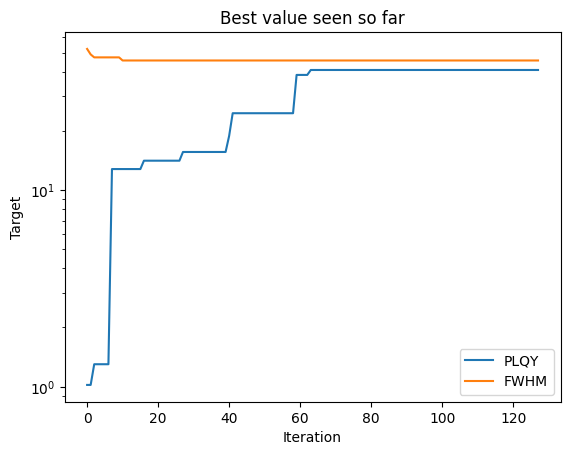

In [8]:
# Plot optimization results
data = optimizer.get_df_from_pymoo()
data = optimizer.rescale_dataframe(data, params)
all_metrics = optimizer.all_metrics
plt.figure()
for i, metric in enumerate(all_metrics):
    if suggest.minimize[i]:
       plt.plot(np.minimum.accumulate(data[metric]), label=metric)
    else:
       plt.plot(np.maximum.accumulate(data[metric]), label=metric)

plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Target")
plt.legend()
plt.title("Best value seen so far")

plt.show()

In [9]:
# print the parameters to that are running in data
print("Parameters to run next:")
print(to_run_next)

Parameters to run next:
   Cs_fraction  Fa_fraction  Spin_duration_Antisolvent  \
0     0.416667     0.581196                  25.045924   
1     0.202270     0.645164                  29.429907   
2     0.513405     0.026391                   7.333619   
3     0.338730     0.011037                  10.761647   
4     0.078995     0.774708                  17.743361   
5     0.115885     0.459397                  28.118912   

   Spin_duration_High_Speed   Spin_speed  
0                 38.806388  1074.957957  
1                 23.239018  1746.335826  
2                 42.246583  4248.038384  
3                 56.328715  2814.421275  
4                 32.257086  3613.080083  
5                 36.025991  2997.485987  


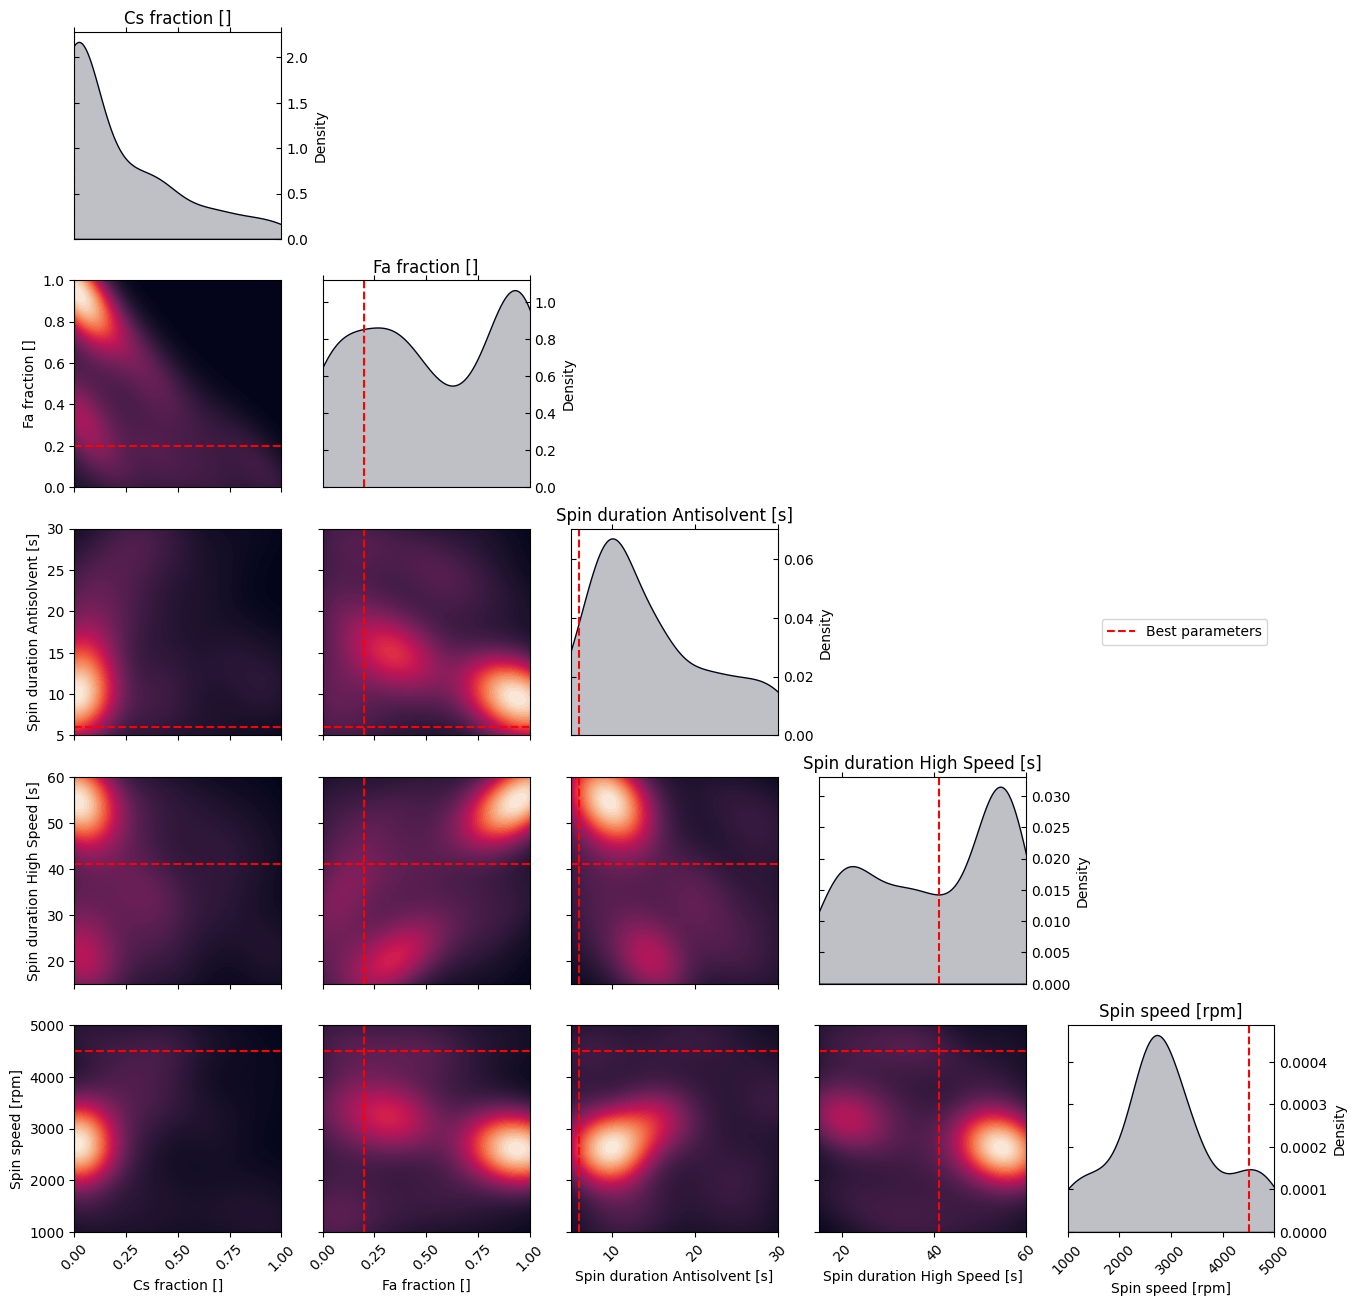

In [10]:
# Plot the density of the exploration of the parameters
# this gives a nice visualization of where the optimizer focused its exploration and may show some correlation between the parameters
plot_dens = True
if plot_dens:
    from optimpv.posterior.exploration_density import *
    params_orig_dict, best_parameters = {}, {}
    for p in optimizer.params:
        best_parameters[p.name] = p.value

    fig_dens, ax_dens = plot_density_exploration(params, optimizer = optimizer, best_parameters = best_parameters,  optimizer_type = 'pymoo')
